# 01 — EDA: Bus Segment Travel-Time Prediction

**Tujuan:** memahami struktur data, membongkar dua jebakan kritis
(leakage `average_time_sec`; `no_do` vs `trip_id` sebagai unit loop), menetapkan
threshold cleaning, dan menemukan identitas target. Semua angka **direproduksi dari
parquet mentah**; logika reusable hidup di `src/`. Keputusan dicatat di `DECISIONS.md`.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_raw, validate_raw, add_gap_flag

raw = load_raw()
print("shape:", raw.shape)
validate_raw(raw)

shape: (351103, 11)


{'rows': 351103,
 'n_no_do': 17857,
 'n_trip_id': 13,
 'n_segment_id': 44,
 'n_route_code': 1,
 'nulls_total': 0,
 'time_min': Timestamp('2026-02-01 00:00:21'),
 'time_max': Timestamp('2026-02-28 23:59:30'),
 'target_vs_timestamp_max_diff_sec': 0.9980000000000047,
 'median_segments_per_loop': 19.0}

## A. Struktur & jebakan #1 — `no_do` adalah unit loop, BUKAN `trip_id`
`trip_id` hanya 13 nilai untuk 351k baris (~27rb baris/trip → mustahil satu loop fisik):
itu **varian rute**. `no_do` = 17.857 loop, median 19 segmen, `stop_sequence` urut rapi
di dalamnya → **inilah satu putaran**. Implikasi: sequence key LSTM & Loop MAE pakai `no_do`.

In [2]:
for c in ["route_code", "trip_id", "no_do", "segment_id", "bus_body_no"]:
    print(f"{c:14s}: {raw[c].nunique()} unik")
seg = raw.groupby("no_do").size()
print(f"\nsegmen/loop: median={seg.median():.0f}, range={seg.min()}-{seg.max()}")
print(f"rata-rata baris/trip_id: {len(raw)/raw['trip_id'].nunique():.0f}")

route_code    : 1 unik
trip_id       : 13 unik
no_do         : 17857 unik
segment_id    : 44 unik


bus_body_no   : 259 unik

segmen/loop: median=19, range=1-72
rata-rata baris/trip_id: 27008


## B. Jebakan #2 — `average_time_sec` adalah TARGET LEAKAGE
`deviation_ratio = traveling/average` ter-cap **persis di [0, 2]** dengan **0% di atas 2**.
Itu mustahil untuk baseline historis nyata (macet/insiden → rasio >2×). Korelasi 0.84.
Empiris (ablation di `03`): menambahkannya memangkas MAE ~44%. → **jangan dipakai mentah**;
kita recompute baseline leakage-free (expanding mean per (segment,hour), di-shift).

deviation_ratio: min=0.000 median=0.999 max=2.000 | %>2.0 = 0.0000%
corr(traveling, average) = 0.840


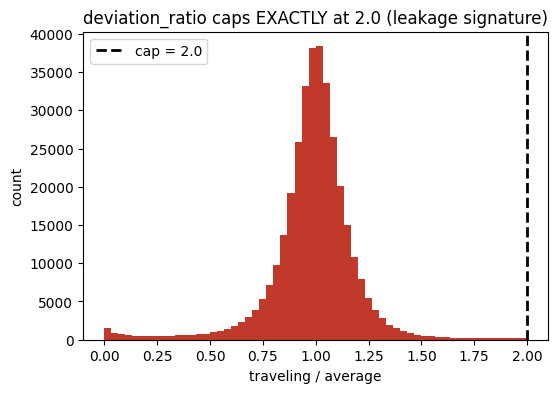

In [3]:
ratio = raw["traveling_time_sec"] / raw["average_time_sec"].replace(0, np.nan)
print(f"deviation_ratio: min={ratio.min():.3f} median={ratio.median():.3f} "
      f"max={ratio.max():.3f} | %>2.0 = {100*(ratio>2).mean():.4f}%")
print(f"corr(traveling, average) = {raw[['traveling_time_sec','average_time_sec']].corr().iloc[0,1]:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(ratio.clip(0, 2.5).dropna(), bins=60, color="#c0392b")
ax.axvline(2.0, ls="--", c="k", lw=2, label="cap = 2.0")
ax.set(title="deviation_ratio caps EXACTLY at 2.0 (leakage signature)",
       xlabel="traveling / average", ylabel="count"); ax.legend(); plt.show()

## C. Skewness ekstrem + outlier
Skew mentah 58 → `log1p` 2.2. Max 958.259 dtk (~11 hari) = mustahil untuk satu segmen.
Patahan tajam p99=32mnt (wajar) → p99.5=6.6jam (mustahil) → **threshold drop > 3600s (1 jam)**.

target: median=89.1s mean=467.3s max=958259.7s
skew raw=58.33 -> log1p=2.21
  p99.0 = 1910s (31.8 min)
  p99.5 = 23691s (394.8 min)
  p99.9 = 44467s (741.1 min)


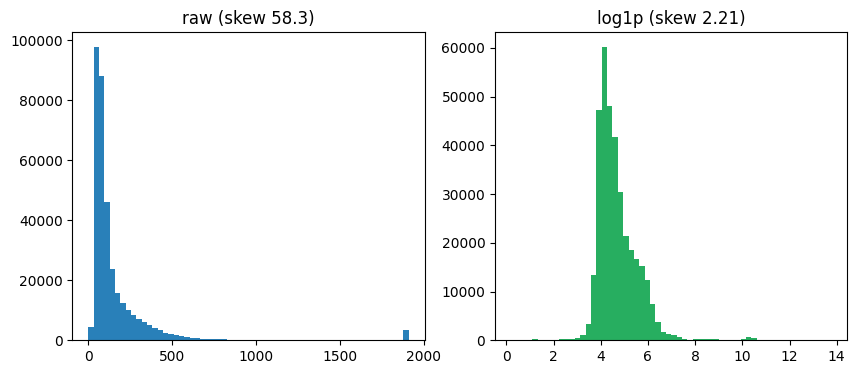

In [4]:
t = raw["traveling_time_sec"]
print(f"target: median={t.median():.1f}s mean={t.mean():.1f}s max={t.max():.1f}s")
print(f"skew raw={t.skew():.2f} -> log1p={np.log1p(t).skew():.2f}")
for q in [0.99, 0.995, 0.999]:
    print(f"  p{q*100:.1f} = {t.quantile(q):.0f}s ({t.quantile(q)/60:.1f} min)")
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].hist(t.clip(0, t.quantile(.99)), bins=60, color="#2980b9"); axs[0].set_title(f"raw (skew {t.skew():.1f})")
axs[1].hist(np.log1p(t), bins=60, color="#27ae60"); axs[1].set_title(f"log1p (skew {np.log1p(t).skew():.2f})")
plt.show()

## D. Incomplete trips (gap) & sparsity
47.4% loop punya gap (`stop_sequence.diff()>1`); 179 loop hanya 1 segmen.
Sparsity ringan: hanya 3.3% kombinasi (segment,hour) punya <30 observasi.

loop bergap: 8458/17857 = 47.4%
(segment,hour) combos=1029 | <30 obs=3.3% | <10 obs=0.9%


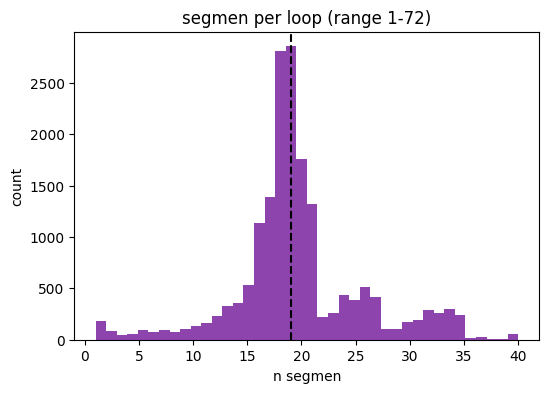

In [5]:
flagged = add_gap_flag(raw)
loops_gap = int(flagged.groupby("no_do")["is_gap_suspected"].first().sum())
print(f"loop bergap: {loops_gap}/{flagged['no_do'].nunique()} = {100*loops_gap/flagged['no_do'].nunique():.1f}%")
raw_h = raw.assign(hour=raw["departure_time"].dt.hour)
sh = raw_h.groupby(["segment_id", "hour"]).size()
print(f"(segment,hour) combos={len(sh)} | <30 obs={100*(sh<30).mean():.1f}% | <10 obs={100*(sh<10).mean():.1f}%")
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(seg.clip(0, 40), bins=40, color="#8e44ad"); ax.axvline(seg.median(), ls="--", c="k")
ax.set(title="segmen per loop (range 1-72)", xlabel="n segmen", ylabel="count"); plt.show()

## E. Temuan kunci: target = selisih timestamp → `arrival_time` post-hoc
`traveling_time_sec == arrival_time − from_arrival_time_str` untuk **100% baris** (<1s).
Artinya `arrival_time` baru ada **setelah** segmen selesai → memakainya = leakage.
**Semua fitur waktu diambil dari `from_arrival_time_str` (departure).**

In [6]:
delta = (raw["arrival_time"] - raw["departure_time"]).dt.total_seconds()
print(f"max |delta - traveling| = {(delta - raw['traveling_time_sec']).abs().max():.3f}s")
print(f"baris arrival < departure: {(delta < 0).sum()}")
print(f"span DEPARTURE: {raw['departure_time'].min()} .. {raw['departure_time'].max()} "
      f"(= Februari, {raw['departure_time'].dt.normalize().nunique()} hari)")

max |delta - traveling| = 0.998s
baris arrival < departure: 0
span DEPARTURE: 2026-02-01 00:00:21 .. 2026-02-28 23:59:30 (= Februari, 28 hari)


## Ringkasan keputusan (detail di `DECISIONS.md`)
- **D2** `average_time_sec` leakage → recompute baseline bersih.
- **D3** drop `traveling_time_sec > 3600s` (0.85% baris).
- **D4** `is_gap_suspected = diff>1`; kebijakan drop spesifik-model (tabular simpan+flag).
- **D6** split time-based loop-aware, cut 2026-02-22 (test = 7 hari terakhir).
- **D11** fitur waktu dari departure; `arrival_time` di-drop.